In [13]:
import re
import os
from collections import defaultdict

Для всех задач, где формулировка вида "найдите в тексте", тексты для проверки вы можете выбирать абсолютно любые. 

#### Задача 1. 

Найдите в тексте все смайлики вида :), :(, :-), :-(.

In [14]:
text = "смайлики такие :) :( потом такие :-) :-( и вот такие :--(( :))))"
matches = re.findall(r":-*(?:\(|\))+" , text)
print(matches)  # [':)', ':(', ':-)', ':-(']

[':)', ':(', ':-)', ':-(', ':--((', ':))))']


#### Задача 2.

Некоторые любят выделять особо важные места в тексте с помощью нижнего подчёркивания, например: "...здесь \_очень важно\_ отметить..." (дело в том, что нижние подчеркивания в некоторых редакторах автоматически превращаются в курсив).

Ищем такие выделения, но не длиннее 5 слов.

In [15]:
text = "«Фундаментальная и прикладная лингвистика» — __флагманская программа Института лингвистики__, она существует с момента основания института и опирается на __последние достижения__ современной науки о языке. Подготовка студентов бакалавриата направлена на приобретение комплексных знаний и умений, необходимых профессиональному лингвисту. __Что всё это значит — и как понять, нужно ли это вам?__"
matches = re.findall(r"_(?:\w+\s?){1,5}_", text)
print(matches)  # ['_очень важно_', '_это ключевая мысль_', '_тоже важно отметить_']


['__флагманская программа Института лингвистики__', '__последние достижения__']


#### Задача 3.

Найдите в тексте все куски, которые взяты в круглые скобки. 

In [16]:
text = "Во-первых, если вы поступите (на ФиПЛ), то научитесь ориентироваться в ключевых вопросах теоретической лингвистики сегодняшнего дня: что такое (языковая способность? как вообще) устроены языки (а их примерно 6000!)? как мы их используем в реальной жизни — и что обо всём этом думают учёные сейчас и думали раньше? какие языки родственны друг другу и откуда мы об этом знаем? почему некоторые явления возможны и даже необходимы во всех языках, некоторые встречаются совсем редко, а каких-то не бывает вообще?"
matches = re.findall(r"\((.*?)\)", text)
print(matches)

['на ФиПЛ', 'языковая способность? как вообще', 'а их примерно 6000!']


#### Задача 4.

С помощью os.listdir() обходим все файлы с музыкой в папке; при этом в папке, которую мы обходим, нужные нам файлы называются в таком формате:

    имя исполнителя - номер песни - название песни.mp3
    
(при этом дефисы могут попасться как в имени исполнителя, так и в названии песни тоже). Программа должна:

1. Обрабатывать только файлы, которые удовлетворяют этому шаблону (открывать их не будем, давайте будем просто сообщать, что X - это песенка исполнителя Y)
2. По итогам работы собрать статистику с перечнем исполнителей и их песен в виде:

        имя исполнителя:
            номер песни. название песни
        имя исполнителя:
            номер песни. название песни

In [17]:
def process_music_folder(folder_path):
    pattern = r"(.+?) - (\d+) - (.+?)\.mp3"
    music_stats = defaultdict(list)

    for file_name in os.listdir(folder_path):
        match = re.match(pattern, file_name)        
        if match:
            artist = match.group(1)  
            song_number = match.group(2)  
            song_name = match.group(3) 

            music_stats[artist].append(f"{song_number}. {song_name}")
            print(f"{file_name} — это песенка исполнителя {artist}")

    print("\nстатистика:")
    for artist, songs in music_stats.items():
        print(f"{artist}:")
        for song in sorted(songs):  
            print(f"    {song}")

folder_path = "C:\\Users\\Anastasia\\Desktop\\songs"
process_music_folder(folder_path)


Asyl-zhan - 1 - S.O.S.mp3 — это песенка исполнителя Asyl-zhan
Dodo-dowson feat. Atlass - 2 - Ystyq bolsyn dala.mp3 — это песенка исполнителя Dodo-dowson feat. Atlass
Etje feat. Скриптонит & Кайрат Нуртас - 3 - Поворот х күттім-ай (Mash up).mp3 — это песенка исполнителя Etje feat. Скриптонит & Кайрат Нуртас

статистика:
Asyl-zhan:
    1. S.O.S
Dodo-dowson feat. Atlass:
    2. Ystyq bolsyn dala
Etje feat. Скриптонит & Кайрат Нуртас:
    3. Поворот х күттім-ай (Mash up)


скрин папки: 

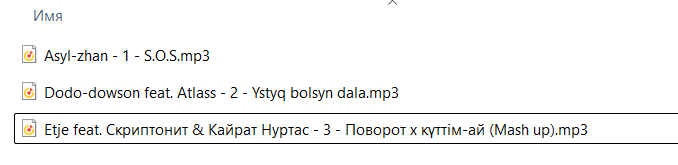

#### Задача 5.

В файле 26.txt содержатся сырые выкачанные из интернета новостные тексты. Извлеките сами тексты из файла. BeautifulSoup пользоваться пока нельзя. 

In [18]:
with open('26.txt', 'r', encoding='utf-8') as file:
    content = file.read()

pattern = r"<text><o>\s*(.*?)\s*</o></text>"
texts = re.findall(pattern, content, re.DOTALL)

for i, text in enumerate(texts, 1):
    print(f"статья {i}:\n{text.strip()}\n")


статья 1:
В Томской области 14 июля совершил аварийную посадку вертолет Ми-8. Как  сообщает  региональное управление МЧС, пострадали семь человек, погибших нет. 
 По предварительным данным, вертолет опрокинулся на бок практически сразу после взлета с посадочной площадки Игольско-Талового нефтяного месторождения на севере Томской области. На борту находились 17 человек, в том числе три члена экипажа. Как сообщил  РИА Новости  представитель оперативного штаба, четверо пострадавших находятся в тяжелом состоянии. 
 По словам источника  «Интерфакса» , вертолет принадлежал компании «Газпром авиа». Причины аварии пока не установлены. 
 Это уже не первое за последние годы происшествие с Ми-8 на площадке Игольско-Талового месторождения. В декабре 2010 года вертолет сгорел во время подготовки к взлету. Причиной инцидента стал взрыв теплогенератора, которым разогревали двигатель машины. Пострадавших тогда не было.

статья 2:
Сотни человек вышли на улицы США в знак протеста против оправдательного 

#### Задача 6.

Достаньте не только тексты из файла 26.txt, но и даты их создания - одним регулярным выражением, чтобы возвращались кортежи "текст - дата". 

In [19]:
with open('26.txt', 'r', encoding='utf-8') as file:
    content = file.read()

pattern = r"<text><o>\s*(.*?)\s*</o></text>\s*<datetime>(.*?)</datetime>"
matches = re.findall(pattern, content, re.DOTALL)

for i, (text, date) in enumerate(matches, 1):
    print(f"статья {i} (дата: {date}):\n{text.strip()}\n")


статья 1 (дата: 11:21, 14 июля 2013):
В Томской области 14 июля совершил аварийную посадку вертолет Ми-8. Как  сообщает  региональное управление МЧС, пострадали семь человек, погибших нет. 
 По предварительным данным, вертолет опрокинулся на бок практически сразу после взлета с посадочной площадки Игольско-Талового нефтяного месторождения на севере Томской области. На борту находились 17 человек, в том числе три члена экипажа. Как сообщил  РИА Новости  представитель оперативного штаба, четверо пострадавших находятся в тяжелом состоянии. 
 По словам источника  «Интерфакса» , вертолет принадлежал компании «Газпром авиа». Причины аварии пока не установлены. 
 Это уже не первое за последние годы происшествие с Ми-8 на площадке Игольско-Талового месторождения. В декабре 2010 года вертолет сгорел во время подготовки к взлету. Причиной инцидента стал взрыв теплогенератора, которым разогревали двигатель машины. Пострадавших тогда не было.

статья 2 (дата: 15:49, 14 июля 2013):
Сотни человек вы

#### Задача 7. 

Найдите в тексте смайлики вида \*_\*, \^_\^, T_T (а смайлики вида o_O нам не нужны).

In [20]:
text = "*_*, ^^, T_T, o_O, c_c, =_=, ._."

pattern = r"([a-zA-Z!\"#$%&'()*+,-./:;<=>?@[\\\]^_`{|}~])(?:_\1|\1)"

matches = re.findall(pattern, text)

result = []
for match in matches:
    if f"{match}_{match}" in text:  # смайлики с _
        smilie = f"{match}_{match}"
    elif f"{match}{match}" in text:  # смайлики без _
        smilie = f"{match}{match}"
    else:
        continue
    if smilie not in result:  # без повторов
        result.append(smilie)

print(result)


['*_*', '^^', 'T_T', 'c_c', '=_=', '._.']


#### Задача 8. 

Пишем программу - помощник обнаружения тавтологии: ищем в тексте повторяющиеся слова, которые находятся на расстоянии от 2 до 10 слов друг от друга. В простом случае считаем, что пунктуации у нас нет, в сложном можете попробовать ее тоже учесть. 

In [22]:
def find_tautologies(text, stop_words=None):
    if stop_words is None:
        # выкинула часто повторяющиеся
        stop_words = {"и", "в", "не", "ни", "что", "как", "по", "но", "то", "на", "у", "бы", "за", "же", "с", "так", "ли"}

    words = text.split()
    tautologies = []

    # идем по каждому слову
    for i, word in enumerate(words):
        if word.lower() in stop_words:  # пропускаем стоп-слова (господи прости)
            continue

        # ищем это слово в диапазоне от 2 до 10 слов вперед
        for j in range(i + 2, min(i + 11, len(words))):
            if words[j].lower() == word.lower():  # без учета регистра
                tautologies.append((word, i, j))

    return tautologies

text = "Но у Гарри было скверное предчувствие, что под давлением мистера Малфоя Комиссия по обезвреживанию опасных существ уже приняла решение. К Драко, поутихшему после гриффиндорского триумфа в Кубке по квиддичу, в последние дни явно вернулись прежняя наглость и апломб. По ехидным замечаниям, случайно долетевшим до Гарри, было ясно, что у Малфоя нет сомнений в предстоящей казни Клювокрыла, и он весьма доволен тем, что способствовал этому. При теперешних обстоятельствах единственное, что мог сделать Гарри — изо всех сил сдерживать себя, чтобы вслед за Гермионой не закатить ему хорошую оплеуху. Но хуже всего было то, что у друзей не было ни времени, ни возможности навестить Хагрида, поскольку драконовские меры безопасности никто не отменял, а у Гарри не хватало духа пойти и забрать мантию-невидимку из подземелья под одноглазой горбуньей."

tautologies = find_tautologies(text)

for word, pos1, pos2 in tautologies:
    print(f"повторение слова '{word}' на позициях {pos1} и {pos2}")


повторение слова 'было' на позициях 90 и 96


In [23]:
def find_tautologies_w_punct(text, stop_words=None):
   
    if stop_words is None:
        stop_words = {"и", "в", "не", "ни", "что", "как", "по", "но", "то", "на", "у", "бы", "за", "же", "с", "так", "ли"}
    
    # список слов с их позициями
    words_with_positions = [(match.group(), match.start()) for match in re.finditer(r"\b[\w'-]+\b", text)]

    # преобразуем в нижний регистр для проверки повторений
    cleaned_words = [word.lower() for word, _ in words_with_positions]

    tautologies = []

    for i, word in enumerate(cleaned_words):
        if word in stop_words:  
            continue
        
        for j in range(i + 2, min(i + 11, len(cleaned_words))):
            if cleaned_words[j] == word: 
                # добавляем оригинальные слова и их позиции
                tautologies.append((words_with_positions[i], words_with_positions[j]))

    return tautologies

text = """Но у Гарри было скверное предчувствие, что под давлением мистера Малфоя Комиссия по обезвреживанию опасных существ уже приняла решение. К Драко, поутихшему после гриффиндорского триумфа в Кубке по квиддичу, в последние дни явно вернулись прежняя наглость и апломб. По ехидным замечаниям, случайно долетевшим до Гарри, было ясно, что у Малфоя нет сомнений в предстоящей казни Клювокрыла, и он весьма доволен тем, что способствовал этому. При теперешних обстоятельствах единственное, что мог сделать Гарри — изо всех сил сдерживать себя, чтобы вслед за Гермионой не закатить ему хорошую оплеуху. Но хуже всего было то, что у друзей не было ни времени, ни возможности навестить Хагрида, поскольку драконовские меры безопасности никто не отменял, а у Гарри не хватало духа пойти и забрать мантию-невидимку из подземелья под одноглазой горбуньей."""

tautologies = find_tautologies_w_punct(text)

for (word1, pos1), (word2, pos2) in tautologies:
    print(f"повторение слова '{word1}' на позициях {pos1} и {pos2}")


повторение слова 'было' на позициях 608 и 633


#### Задача 9. 

Представим, что есть некоторые данные, представляющие из себя последовательность символов. С помощью регулярного выражения надо найти в них подпоследовательности, являющимися палиндромами, длины не менее 6-ти и не более 11 символов. (Подумайте, а хорошо ли подходят регулярные выражения для решения этой задачи?)

In [24]:
def find_palindromes(sequence):
    
    palindromes = []

    # перебор всех подпоследовательностей длиной от 6 до 11
    for start in range(len(sequence)):
        for length in range(6, 12):  # проверяем длины от 6 до 11
            end = start + length
            if end > len(sequence):  # выходим за пределы строки
                break
            substring = sequence[start:end]
            if substring == substring[::-1]:  # проверяем палиндром ли это
                palindromes.append(substring)

    # убираем дубликаты, если они есть
    return list(set(palindromes))

sequence = "abccba123321notapalindromeabcddcbaaaaabbaaaaaaa"

# Поиск палиндромов
palindromes = find_palindromes(sequence)

# Вывод результата
print("Найденные палиндромы длиной от 6 до 11 символов:")
for p in palindromes:
    print(p)


Найденные палиндромы длиной от 6 до 11 символов:
abccba
bcddcb
aaaaaaa
aabbaa
aaaaaa
aaaabbaaaa
123321
abcddcba
baaaaab
aaabbaaa


#### Задача 10.

Найти в тексте все употребления слов "понравилось" и "впечатлило" такие, что непосредственно перед ними НЕ стоит "не". Время прошедшее, но род/число могут быть любыми.

In [25]:
def find_posit(text):
    pattern = r"(?<!\bне\s)(понрав\w*|впечатл\w*)"
    matches = re.findall(pattern, text, flags=re.IGNORECASE)

    return matches

text = """
Мне понравилось это выступление. Ему очень понравился фильм.
Нам не понравилась погода. Их впечатлило качество работы, но не впечатлили детали.
"""

result = find_posit(text)

print("найденные слова:")
for word in result:
    print(word)


найденные слова:
понравилось
понравился
впечатлило


#### Задача 11. 

Дан текст, каждая строка является именем некоторого файла (без директории). Напишите регулярное выражение, которое захватывает имена файлов без расширения, при этом интерес представляют только те файлы, у которых расширение не .bat и не .txt.

In [26]:
text = """
file1.txt
script.bat
data.csv
report.pdf
backup.tar.gz
notes.docx
"""

pattern = r"^(.+?)\.(?!bat|txt$)[a-zA-Z0-9]+$"
matches = re.findall(pattern, text, flags=re.MULTILINE)

print("имена файлов без расширений (кроме .bat и .txt):")
for match in matches:
    print(match)


имена файлов без расширений (кроме .bat и .txt):
data
report
backup.tar
notes


#### Задача 12.

Дан текст, каждая строка которого является полным или относительным путём к некоторому файлу.

Напишите регулярное выражение, которое захватывает:
1. директорию, в которой лежит файл;
2. только имя файла (без расширения);
3. только расширение;
При этом:
- нужны только файлы, у которых расширение не .bat и не .txt.
- пути могут быть как в Unix, так и в Windows формате (https://ru.wikipedia.org/wiki/Путь_к_файлу).
- расширение, если оно есть, начинается с точки. Файлы могут быть без расширения вовсе (в этом случае на месте расширения должно стоять None или "")
- скрытые файлы могут начинаться с точки (например, .bashrc - и это не расширение)
- относительный путь может содержать только название файла, в этом случае вместо директории выведите None или ""
- в остальных случаях директория должна заканчиаться на разделитель директорий. Наприемр, в Unix-системах - "/" - это путь к корневой директории.

Требуется получить список из кортежей, каждый кортеж содержит извлечённые данные.

(Расширение в целом может содержать всё, что угодно, но разделителей директорий не может быть в именах файлах и расширениях. https://en.wikipedia.org/wiki/List_of_filename_extensions )

In [27]:
def parse_file_paths(text):
    """
    Функция, парсящая пути с помощью регулярного выражения.
    """
    pattern = r"""
    ^(?:                          # начало строки
        (?P<dir>.+[/\\])          # директория (оканчивается на "/" или "\")
    )?                            # директория может отсутствовать
    (?P<name>\.?[^./\\]+?)        # имя файла (может начинаться с точки, исключая директории)
    (?:\.(?P<ext>[^./\\]+))?$     # расширение файла (может отсутствовать)
    """

    # компиляция регулярки
    regex = re.compile(pattern, re.VERBOSE)

    results = []

    # разбиваем на строки и обрабатываем каждую
    for line in text.splitlines():
        line = line.strip()  # убираем лишние пробелы и символы переноса
        if not line:  # пропускаем пустые строки
            continue

        match = regex.match(line)
        if match:
            directory = match.group("dir") or None  # None, если директории нет
            name = match.group("name")
            ext = match.group("ext") or ""         # "" для файлов без расширения

            # пропускаем файлы с расширением .bat или .txt
            if ext.lower() not in {"bat", "txt"}:
                results.append((directory, name, ext))

    return results


text = r"""
/home/user/.bashrc
/home/user/documents/report.pdf
C:\Windows\System32\cmd.exe
C:\Windows\System32\file.bat
../relative/path/file_without_extension
relative_file.txt
file_with_no_extension
"""

parsed_paths = parse_file_paths(text)

print("распарсенные пути:")
for entry in parsed_paths:
    print(entry)


распарсенные пути:
('/home/user/', '.bashrc', '')
('/home/user/documents/', 'report', 'pdf')
('C:\\Windows\\System32\\', 'cmd', 'exe')
('../relative/path/', 'file_without_extension', '')
(None, 'file_with_no_extension', '')


#### Задача 13.

Увеличить все встретившиеся в тексте четные числа на 1, а нечетные на 2, в том числе и отрицательные. Перед числом может стоять знак. Считаем, что между знаком и числом пробела нет.

In [28]:
def modify_numbers(text):
    
    # регулярное выражение для поиска чисел с учетом знака
    pattern = r"(-?\d+)"
    
    # функция замены
    def replace_number(match):
        number = int(match.group())  
        if number % 2 == 0:
            return str(number + 1)  
        else:
            return str(number + 2)  

    # замена чисел в тексте
    modified_text = re.sub(pattern, replace_number, text)
    return modified_text

text = """
2, -3, 10, -11, 0, 15, и даже 42.
"""
modified_text = modify_numbers(text)

print("измененный текст:")
print(modified_text)


измененный текст:

3, -1, 11, -9, 1, 17, и даже 43.



#### Задача 14.

1. Текст состоит из строк (lines). Удалите одним регулярным выражением все пробелы в началах всех строк, и все пробелы в концах всех строк.
2. То же, но теперь не только обычные пробелы, а все пробельные символы. При этом, дополнительно нужно удалить все пустые строки (пустые вообще, а так же состоящие только из пробельных символов). Попробуйте сделать это за одну операцию замены.
3. Сделайте то же самое без регулярных выражений в одну строчку, используя bilt-in функцию filter.

In [29]:
def del_spaces(text):
    # регулярка для удаления пробелов в начале и конце строки
    pattern = r"^\s+|\s+$"
    return re.sub(pattern, "", text, flags=re.MULTILINE)

text = """
    Это пример текста с пробелами в начале и конце.    
  Вторая строка с пробелами.    
      Третья строка.        
"""

# убираем пробелы
result = del_spaces(text)

print("результат после удаления пробелов:")
print(result)

результат после удаления пробелов:
Это пример текста с пробелами в начале и конце.
Вторая строка с пробелами.
Третья строка.


In [30]:
def del_and_remove_empty_lines(text):
    pattern = r"^\s+|\s+$|\n\s*\n"      # все пробельные символы
    return re.sub(pattern, "", text, flags=re.MULTILINE)

text = """
      
    Это пример текста с пробелами и пустыми строками.    
        
  Вторая строка с пробелами.    
      Третья строка.        
      
"""

result = del_and_remove_empty_lines(text)

print("результат после удаления пробелов и пустых строк:")
print(result)

результат после удаления пробелов и пустых строк:
Это пример текста с пробелами и пустыми строками.
Вторая строка с пробелами.
Третья строка.


In [31]:
def trim_and_filter_lines(text):
    # используем filter и strip для удаления пробелов и пустых строк
    return "\n".join(filter(lambda line: line.strip(), map(str.strip, text.splitlines())))

text = """
      
    Это пример текста с пробелами и пустыми строками.    
        
  Вторая строка с пробелами.    
      Третья строка.        
      
"""

result = trim_and_filter_lines(text)

print("результат после удаления пробелов и пустых строк:")
print(result)


результат после удаления пробелов и пустых строк:
Это пример текста с пробелами и пустыми строками.
Вторая строка с пробелами.
Третья строка.


#### Задача 15.

Дан путь к папке. Папка содержит много файлов двух типов: "num_of_words_9_12_4.json" и "9_12_4.txt", где тройка чисел идентифицирует данные, и может быть любой (например, 0_8_0 или 9_13_0 или...). После первого числа иногда может следовать буква 'a', 'b' или 'c', например: "2b_4_8.txt". В папке могут быть файлы и других типов, но схемы их названий выглядят иначе. Для каждого идентификатора в папке, по идее, должен быть и .json, и .txt файл, однако программист, который подготавливал эти данные, допустил ошибку, и поэтому это не так. Напишите программу, которая находит те идентификаторы, для которых нет .json файла, и те, для которых нет .txt файла.

In [32]:
def find_missing_files(folder_path):
    
    json_pattern = r"^num_of_words_(\d+[abc]?)_\d+_\d+\.json$"  
    txt_pattern = r"^(\d+[abc]?)_\d+_\d+\.txt$"  

    # множества для хранения полных названий файлов
    json_files = set()
    txt_files = set()

    # обработка файлов
    for file_name in os.listdir(folder_path):
        if re.match(json_pattern, file_name):
            json_files.add(file_name)  
        elif re.match(txt_pattern, file_name):
            txt_files.add(file_name)  

    # идентификаторы
    json_identifiers = {re.match(json_pattern, file).group(1) for file in json_files}
    txt_identifiers = {re.match(txt_pattern, file).group(1) for file in txt_files}

    # поиск недостающих файлов
    missing_json = {file for file in txt_files if re.match(txt_pattern, file).group(1) not in json_identifiers}
    missing_txt = {file for file in json_files if re.match(json_pattern, file).group(1) not in txt_identifiers}

    return missing_json, missing_txt

folder_path = "C:\\Users\\Anastasia\\Desktop\\hw"  
missing_json, missing_txt = find_missing_files(folder_path)

print("\nидентификаторы файлов без .json файла:")
print(missing_json)

print("\nидентификаторы файлов без .txt файла:")
print(missing_txt)



идентификаторы файлов без .json файла:
{'4_2_2.txt'}

идентификаторы файлов без .txt файла:
{'num_of_words_9b_32_9.json'}


скринчик: 

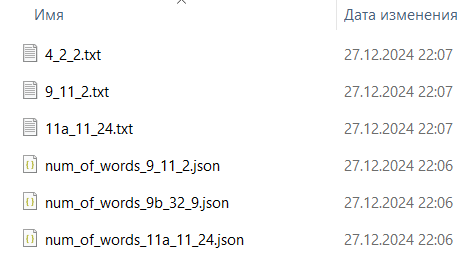